In [1]:
import numpy as np
import pandas as pd

In [2]:
# 1. loading the dataset.csv file into pandas df
df = pd.read_csv("../data/raw/dataset.csv")
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements,loss_of_balance,unsteadiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Performing Data Engineering

In [3]:
# spaces for found for symptoms across the dataset. So removing them.
for col in df.columns:
    df[col] = df[col].str.strip()

# get list of all unique symptoms
symptoms = pd.unique(df.iloc[:, 1:].values.ravel('K'))
symptoms

pd.Series(symptoms).isna().any()
# lets remove NaN values
pd.Series(symptoms).isna().any()
symptoms = [s for s in symptoms if pd.notna(s)]
pd.Series(symptoms).isna().any()

# lets prepare the input features X with these symptoms as columns.
X = pd.DataFrame(np.zeros((len(df), len(symptoms))), columns=symptoms)
X

,itching,skin_rash,continuous_sneezing,shivering,stomach_pain,acidity,vomiting,indigestion,muscle_wasting,patches_in_throat,...,abnormal_menstruation,receiving_unsterile_injections,coma,sinus_pressure,palpitations,stomach_bleeding,runny_nose,congestion,blood_in_sputum,loss_of_smell
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4916,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# One way to write. Takes few seconds to execute

In [4]:
# 7.2 Populate severity value as per symptom
'''# Convert the two columns into a dictionary

# disease_severity_dict = pd.Series(df.Severity.values, index=df.Disease).to_dict()

# Access instantly by disease name

# print(disease_severity_dict.get("Diabetes"))
# Output: 'Moderate'
'''
# # symptom_weight_dict = pd.Series(severity.weight.values, index=severity.Symptom).to_dict()
# symptom_weight_dict = dict(zip(severity["Symptom"], severity["weight"]))
# for i in range(len(X)):
#     row_symptom = df.iloc[i, 1:].dropna().values
#     for j in row_symptom:
#         symptom_weight = symptom_weight_dict.get(j)
#         X.loc[i, j] = symptom_weight
# display(X.shape)
# X.head()

'# Convert the two columns into a dictionary\n\n# disease_severity_dict = pd.Series(df.Severity.values, index=df.Disease).to_dict()\n\n# Access instantly by disease name\n\n# print(disease_severity_dict.get("Diabetes"))\n# Output: \'Moderate\'\n'

# Fastest way with Pandas

In [5]:
# lets now map this dataset with severity weights from the other dataset
severity = pd.read_csv("../data/raw/Symptom-severity.csv")

severity_dict = dict(zip(severity['Symptom'], severity['weight']))
severity_dict

{'itching': 1,
 'skin_rash': 3,
 'nodal_skin_eruptions': 4,
 'continuous_sneezing': 4,
 'shivering': 5,
 'chills': 3,
 'joint_pain': 3,
 'stomach_pain': 5,
 'acidity': 3,
 'ulcers_on_tongue': 4,
 'muscle_wasting': 3,
 'vomiting': 5,
 'burning_micturition': 6,
 'spotting_urination': 6,
 'fatigue': 4,
 'weight_gain': 3,
 'anxiety': 4,
 'cold_hands_and_feets': 5,
 'mood_swings': 3,
 'weight_loss': 3,
 'restlessness': 5,
 'lethargy': 2,
 'patches_in_throat': 6,
 'irregular_sugar_level': 5,
 'cough': 4,
 'high_fever': 7,
 'sunken_eyes': 3,
 'breathlessness': 4,
 'sweating': 3,
 'dehydration': 4,
 'indigestion': 5,
 'headache': 3,
 'yellowish_skin': 3,
 'dark_urine': 4,
 'nausea': 5,
 'loss_of_appetite': 4,
 'pain_behind_the_eyes': 4,
 'back_pain': 3,
 'constipation': 4,
 'abdominal_pain': 4,
 'diarrhoea': 6,
 'mild_fever': 5,
 'yellow_urine': 4,
 'yellowing_of_eyes': 4,
 'acute_liver_failure': 6,
 'fluid_overload': 4,
 'swelling_of_stomach': 7,
 'swelled_lymph_nodes': 6,
 'malaise': 6,
 'bl

In [6]:
df['patient_id'] = df.index
symptom_cols = df.columns[1:].str.strip()
symptom_cols
# sample.values
# lets start melting
melted = df.melt(id_vars='patient_id', value_vars=symptom_cols, value_name='Symptom_name')
melted

# lets drop NaN rows
melted = melted.dropna(subset=['Symptom_name'])

# lets map weights
melted['weight'] = melted['Symptom_name'].map(severity_dict).fillna(1)

# Lets pivot it back to X and fill any null values with default weight 1s.
X = melted.pivot(index='patient_id', columns='Symptom_name', values='weight').fillna(0)
X

Symptom_name,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
patient_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4916,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Lookup a sample

In [7]:
# patient_zero = X.loc[0]
# patient_zero[patient_zero > 0]
patient_zero = X.loc[7]
print(patient_zero[patient_zero > 0])

Symptom_name
dischromic _patches    1.0
itching                1.0
skin_rash              3.0
Name: 7, dtype: float64


In [8]:
y = df.pop('Disease')

In [9]:
y = np.array(y)

In [10]:
y

array(['Fungal infection', 'Fungal infection', 'Fungal infection', ...,
       'Urinary tract infection', 'Psoriasis', 'Impetigo'],
      shape=(4920,), dtype=object)

## Lets one hot encode the labels

In [11]:
diseases, indices = np.unique(y, return_inverse=True)
diseases, indices

(array(['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne',
        'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma',
        'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis',
        'Common Cold', 'Dengue', 'Diabetes',
        'Dimorphic hemmorhoids(piles)', 'Drug Reaction',
        'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack',
        'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
        'Hypertension', 'Hyperthyroidism', 'Hypoglycemia',
        'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine',
        'Osteoarthristis', 'Paralysis (brain hemorrhage)',
        'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis',
        'Typhoid', 'Urinary tract infection', 'Varicose veins',
        'hepatitis A'], dtype=object),
 array([15, 15, 15, ..., 38, 35, 27], shape=(4920,)))

In [12]:
one_hot = np.zeros((y.size, diseases.size), dtype=int)
one_hot

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4920, 41))

In [13]:
one_hot[np.arange(len(y)), indices] = 1
one_hot

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4920, 41))

## Saving y

In [14]:
np.save('../data/processed/disease_classes.npy', diseases)

# Perform Train Test Split

### Observation: Dataset is populated with permutations of diseases in obvious sequences. Splitting without randomly picking the train and test data can impact learning.

In [15]:
np.random.seed(42) # to be able to reproduce this

# generate a list of indices 0 to len(X). Then randomising them.
randomized_indices = np.random.permutation(len(X))
randomized_indices

pivot = int(0.8 * len(X))
display(pivot)

X_train = X.values[randomized_indices[ : pivot]]
X_test = X.values[randomized_indices[pivot : ]]

y_train = one_hot[randomized_indices[ : pivot]]
y_test = one_hot[randomized_indices[pivot : ]]

print(f'Before typecasting: {type(X_train[0][1])}')

'''
When we used the melt() and pivot() functions earlier, Pandas sometimes defaults the final matrix 
to an object data type instead of a pure number.

When NumPy sees an object matrix, it panics and Abandons its ultra-fast C-optimizations, 
falling back to a much slower computation method.

Before you pass your data into the model, forcefully convert it to 64-bit floats
'''
X_train = X_train.astype(np.float64)
y_train = y_train.astype(np.float64)

print(f'After typecasting: {type(X_train[0][1])}')

# X_train.shape (patients, symptoms), y_train.shape (disease)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape, sep='\n')

3936

Before typecasting: <class 'numpy.float64'>
After typecasting: <class 'numpy.float64'>
(3936, 131)
(984, 131)
(3936, 41)
(984, 41)


In [16]:
randomized_indices

array([ 373, 4916, 1550, ..., 3092, 3772,  860], shape=(4920,))

# Some important Formulae

## To find the probability of a specific class, take the exponent of its raw score, and divide it by the sum of the exponents of all the raw scores.

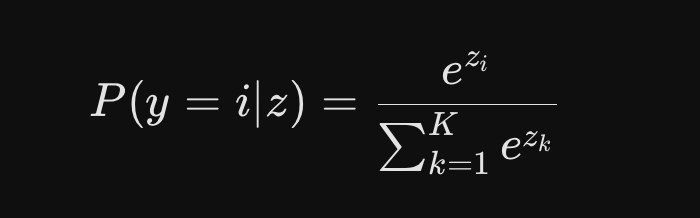

## Loss is defined as -(1 / n) * sum of all samples(sum (product (truth label of nth sample is class k, log(predicted class k))))

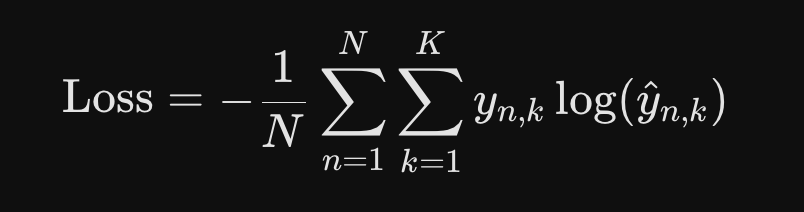

In [17]:
class SoftmaxRegression:
    def __init__(self, epochs=1000, lr=0.01):
        self.epochs = epochs
        self.lr = lr
        self.weights = None
        self.bias = None
        self.losses = []

    def _softmax(self, Z):
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_z = np.exp(Z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _intialise_weights(self, n_features, k_classes):
        self.weights = np.random.randn(n_features, k_classes) * 0.01
        self.bias = np.zeros((1, k_classes))

    def _cross_entropy_loss(self, n_samples, y, probs):
        y_probs = np.clip(probs, 1e-15, 1 - 1e-15)
        return -(1 / n_samples) * np.sum(y * np.log(y_probs))

    def fit(self, X, y):
        self._intialise_weights(X.shape[1], y.shape[1])
        n_samples = X.shape[0]
        for i in range(self.epochs):
            Z = np.dot(X, self.weights) + self.bias

            probs = self._softmax(Z)

            error = probs - y

            # the math of matrix multiplication automatically sums up the values across all your samples. 
            #Hence no use of np.sum(np.dot())
            dw = (1 / n_samples) * np.dot(X.T, error)
            # error is a matrix of (N, 41). You have N different errors. You need one single bias adjustment for each of the 41 classes. 
            # You must sum the errors vertically across all patients.
            db = (1 / n_samples) * np.sum(error, axis=0, keepdims=True)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = self._cross_entropy_loss(n_samples, y, probs)
            self.losses.append(loss)
            if i % 100 == 0:
                print(f'Loss at epoch {i} is {loss:.4f}')

        return self

    def _predict(self, X):
        """
        Predicts the disease class for the given symptoms.
        """
        Z = np.dot(X, self.weights) + self.bias
        probs = self._softmax(Z)
        return np.argmax(probs, axis=1)
        

In [18]:
model = SoftmaxRegression(epochs=2500, lr=0.01)
trained_model = model.fit(X_train, y_train)

Loss at epoch 0 is 3.7275
Loss at epoch 100 is 1.7339
Loss at epoch 200 is 0.9416
Loss at epoch 300 is 0.6052
Loss at epoch 400 is 0.4344
Loss at epoch 500 is 0.3338
Loss at epoch 600 is 0.2683
Loss at epoch 700 is 0.2226
Loss at epoch 800 is 0.1892
Loss at epoch 900 is 0.1640
Loss at epoch 1000 is 0.1444
Loss at epoch 1100 is 0.1289
Loss at epoch 1200 is 0.1164
Loss at epoch 1300 is 0.1060
Loss at epoch 1400 is 0.0974
Loss at epoch 1500 is 0.0901
Loss at epoch 1600 is 0.0838
Loss at epoch 1700 is 0.0784
Loss at epoch 1800 is 0.0737
Loss at epoch 1900 is 0.0695
Loss at epoch 2000 is 0.0658
Loss at epoch 2100 is 0.0625
Loss at epoch 2200 is 0.0595
Loss at epoch 2300 is 0.0568
Loss at epoch 2400 is 0.0543


## Predict against test data. Output of y_pred

In [19]:
# predict against test data.
y_pred = model._predict(X_test)

# our y_pred looks like
y_pred

array([16, 28, 21, 10, 29, 12, 36, 37,  1, 13, 11,  4, 22, 33, 36, 38,  5,
       16, 20, 11, 14,  5, 33,  2, 30, 21, 25, 31, 18, 20, 32, 38, 22, 27,
       26,  7,  3,  4, 19, 30,  1, 40, 26, 21, 19, 23, 23, 22, 11, 16, 18,
       30,  0, 29, 20, 29, 16,  2, 38, 12, 15, 28, 24,  6, 24, 29, 19, 38,
       36,  1, 33, 12, 36, 33, 40, 13, 33,  8, 40, 21, 26,  7, 20, 21,  3,
        1, 30, 20,  5, 31, 33,  3, 15, 27, 14,  1,  8,  4,  7, 30, 32, 24,
       35,  0, 18, 31, 37, 34, 39, 12,  9, 33,  3, 14,  4, 14,  1, 18, 40,
       38,  4, 13, 28,  6,  6, 31,  7, 36, 20, 24, 14, 12, 30, 40, 39,  9,
        0, 16, 20, 10, 21, 27, 24, 18,  3, 22,  4, 21,  4, 23, 10, 20, 20,
       40, 14, 13, 32, 38, 23, 31, 39, 28, 29, 15, 23, 16,  1, 35, 38, 16,
       13, 25,  5, 15, 23, 38,  5, 29, 19,  4, 28,  1, 11, 28, 26, 39, 17,
       21, 18, 35, 17,  3,  4, 38, 12, 13, 17,  4, 33,  2, 35, 32, 18, 37,
       22, 30, 14,  2, 10, 22, 17,  6,  2, 18, 13, 33, 24,  1,  5,  2, 10,
       24, 30, 24, 38, 22

## but our y_test is one-hot-encoded

In [20]:
y_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(984, 41))

### Gotta convert our encoded labels back to indices

In [21]:
y_true = y_test.argmax(axis=1)
y_true

array([16, 28, 21, 10, 29, 12, 36, 37,  1, 13, 11,  4, 22, 33, 36, 38,  5,
       16, 20, 11, 14,  5, 33,  2, 30, 21, 25, 31, 18, 20, 32, 38, 22, 27,
       26,  7,  3,  4, 19, 30,  1, 40, 26, 21, 19, 23, 23, 22, 11, 16, 18,
       30,  0, 29, 20, 29, 16,  2, 38, 12, 15, 28, 24,  6, 24, 29, 19, 38,
       36,  1, 33, 12, 36, 33, 40, 13, 33,  8, 40, 21, 26,  7, 20, 21,  3,
        1, 30, 20,  5, 31, 33,  3, 15, 27, 14,  1,  8,  4,  7, 30, 32, 24,
       35,  0, 18, 31, 37, 34, 39, 12,  9, 33,  3, 14,  4, 14,  1, 18, 40,
       38,  4, 13, 28,  6,  6, 31,  7, 36, 20, 24, 14, 12, 30, 40, 39,  9,
        0, 16, 20, 10, 21, 27, 24, 18,  3, 22,  4, 21,  4, 23, 10, 20, 20,
       40, 14, 13, 32, 38, 23, 31, 39, 28, 29, 15, 23, 16,  1, 35, 38, 16,
       13, 25,  5, 15, 23, 38,  5, 29, 19,  4, 28,  1, 11, 28, 26, 39, 17,
       21, 18, 35, 17,  3,  4, 38, 12, 13, 17,  4, 33,  2, 35, 32, 18, 37,
       22, 30, 14,  2, 10, 22, 17,  6,  2, 18, 13, 33, 24,  1,  5,  2, 10,
       24, 30, 24, 38, 22

# Accuracy of model on unseen data

In [22]:
accuracy = np.mean(y_true == y_pred)
print(f'Accuracy of model: {accuracy * 100:.2f}%')

Accuracy of model: 100.00%


# Heatmap

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

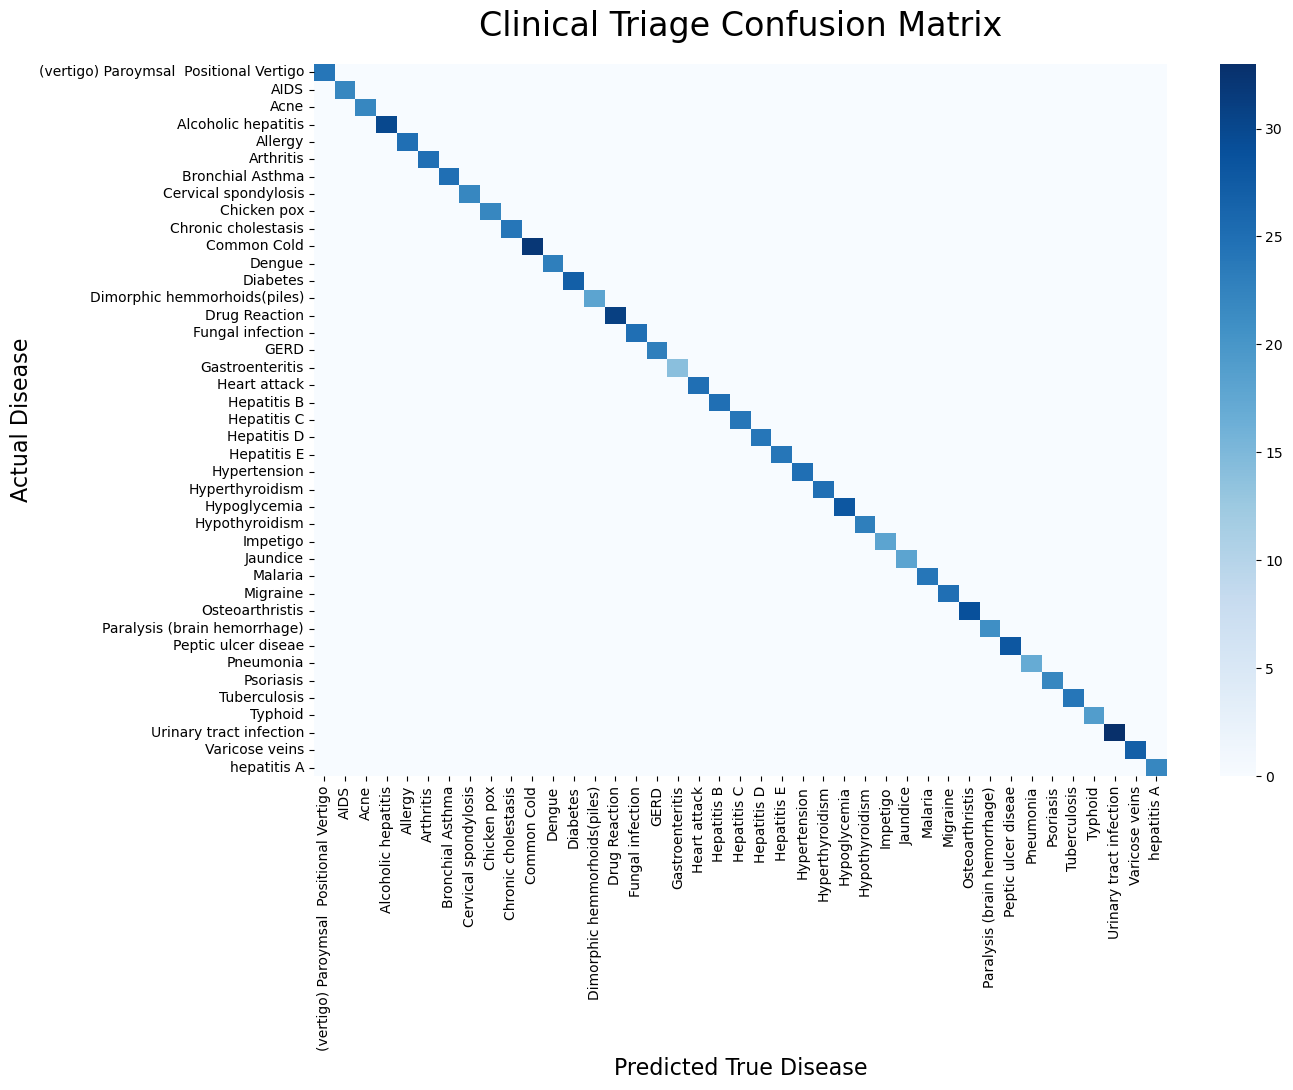

In [24]:
cm = confusion_matrix(y_true, y_pred)
cm

plt.figure(figsize=(14, 11))
sns.heatmap(cm,
            xticklabels=diseases,
            yticklabels=diseases,
            cmap="Blues",
            annot=False
           )

plt.title('Clinical Triage Confusion Matrix', fontsize=24, pad=20)
plt.xlabel('Predicted True Disease', fontsize=16)
plt.ylabel('Actual Disease', fontsize=16)

plt.xticks(rotation=90) 
plt.tight_layout()
plt.show()

# Exporting model artifacts through pickle

In [25]:
import pickle as pkl

model_artifacts = {
    'model_weights': model.weights,
    'model_bias': model.bias,
    'diseases': diseases,
    'symptoms': list(X.columns),
    'symptom_weight': severity_dict
}

with open('../data/processed/clinical_model.pkl', 'wb') as file:
    pkl.dump(model_artifacts, file)

print('Model artifacts were exported Successfully')

Model artifacts were exported Successfully
